In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(75)
X = np.sort(np.arange(0, 1.01, 0.01))
m_true = np.random.uniform(-10, 10)
b_true = np.random.uniform(-5, 5)

error = np.random.uniform(0, 1, size=len(X))
signs = np.random.choice([-1, 1], size=len(X))

Y = m_true * X + b_true + error * signs

In [4]:
def my_least_squares(x, y):
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean)**2)

    m = numerator / denominator
    b = y_mean - m * x_mean

    return m, b

In [5]:

m_my, b_my = my_least_squares(X, Y)
Y_my = m_my * X + b_my
residuals = Y - Y_my

min_res_index = np.argmin(residuals)
min_res = residuals[min_res_index]
min_x = X[min_res_index]
min_y = Y[min_res_index]

max_res_index = np.argmax(residuals)
max_res = residuals[max_res_index]
max_x = X[max_res_index]
max_y = Y[max_res_index]

abs_res_index = np.argmax(np.abs(residuals))
abs_res = residuals[abs_res_index]
abs_x = X[abs_res_index]
abs_y = Y[abs_res_index]

In [6]:

A = np.vstack([X, np.ones(len(X))]).T
m_np, b_np = np.linalg.lstsq(A, Y, rcond=None)[0]

Y_np = m_np * X + b_np


In [7]:

print("TRUE line:      y = m x + b")
print(f"  m_true = {m_true:.5f}, b_true = {b_true:.5f}")

print("\nMY Least Squares:")
print(f"  m_my   = {m_my:.5f}, b_my   = {b_my:.5f}")

print("\nNumPy lstsq:")
print(f"  m_np   = {m_np:.5f}, b_np   = {b_np:.5f}")

print("\nResiduals (MY method):")
print(f"  smallest residual (most negative): r = {min_res:.5f} at x={min_x:.2f}, y={min_y:.5f}")
print(f"  largest residual  (most positive): r = {max_res:.5f} at x={max_x:.2f}, y={max_y:.5f}")
print(f"  largest |residual|: r = {abs_res:.5f} at x={abs_x:.2f}, y={abs_y:.5f}")   

TRUE line:      y = m x + b
  m_true = 1.37880, b_true = -4.34036

MY Least Squares:
  m_my   = 1.21072, b_my   = -4.13344

NumPy lstsq:
  m_np   = 1.21072, b_np   = -4.13344

Residuals (MY method):
  smallest residual (most negative): r = -1.14874 at x=0.23, y=-5.00371
  largest residual  (most positive): r = 0.90452 at x=0.87, y=-2.17560
  largest |residual|: r = -1.14874 at x=0.23, y=-5.00371


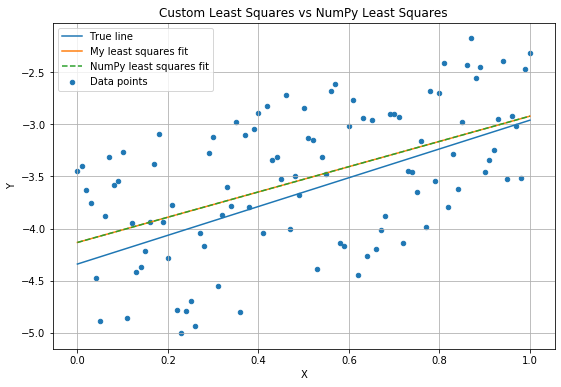

In [8]:
plt.figure(figsize=(9, 6))
plt.scatter(X, Y, s=20, label="Data points")
plt.plot(X, m_true * X + b_true, label="True line")
plt.plot(X, Y_my, label="My least squares fit")
plt.plot(X, Y_np, linestyle="--", label="NumPy least squares fit")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Custom Least Squares vs NumPy Least Squares")
plt.legend()
plt.grid(True)
plt.show()